In [8]:
# Import required libraries for data analysis and visualization

import pandas as pd            # data manipulation
import numpy as np             # numerical operations
import matplotlib.pyplot as plt # plotting
import seaborn as sns           # advanced visualization

# Set visualization style
sns.set(style="whitegrid")

# Load the dataset from the data folder
# "../" moves one directory up from the notebooks folder

df = pd.read_csv("../data/ab_data.csv")

# Display the first few rows to understand the dataset structure
df.head()

# Inspect column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [9]:
# Check if the dataset contains missing values
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [10]:
# Count how many users are in each experiment group
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [11]:
# Verify which landing page corresponds to each group
df.groupby(['group', 'landing_page']).size()

group      landing_page
control    new_page          1928
           old_page        145274
treatment  new_page        145311
           old_page          1965
dtype: int64

In [12]:
# Calculate conversion rate for each experiment group
conversion_rates = df.groupby('group')['converted'].mean()
conversion_rates

group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64

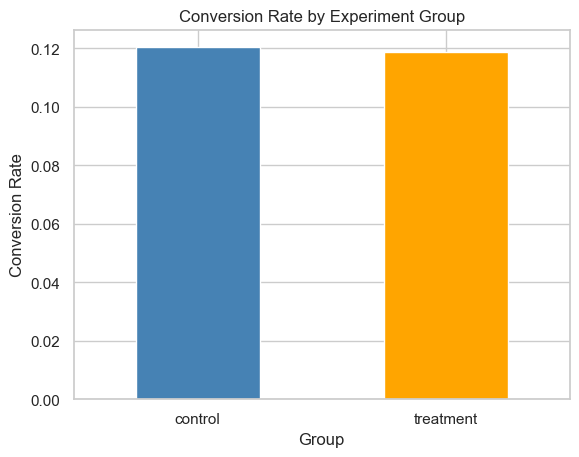

In [13]:
# Create a bar chart to compare conversion rates between groups
conversion_rates.plot(kind='bar', color=['steelblue','orange'])

plt.title("Conversion Rate by Experiment Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.xticks(rotation=0)

plt.show()

In [15]:
# Separate control and treatment groups
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

In [16]:
# Calculate number of successful conversions in each group

control_conversions = control['converted'].sum()
treatment_conversions = treatment['converted'].sum()

control_total = len(control)
treatment_total = len(treatment)

print("Control conversions:", control_conversions)
print("Treatment conversions:", treatment_conversions)

Control conversions: 17723
Treatment conversions: 17514


In [19]:
# Import statistical test library
from statsmodels.stats.proportion import proportions_ztest

# Separate experiment groups
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

# Count conversions
control_conversions = control['converted'].sum()
treatment_conversions = treatment['converted'].sum()

# Count total users
control_total = len(control)
treatment_total = len(treatment)

# Perform two-proportion Z-test
success = [control_conversions, treatment_conversions]
samples = [control_total, treatment_total]

z_stat, p_value = proportions_ztest(success, samples)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 1.2369217547321678
P-value: 0.21611613269757501


In [20]:
# Define significance level
alpha = 0.05

if p_value < alpha:
    print("Result is statistically significant.")
else:
    print("Result is NOT statistically significant.")

Result is NOT statistically significant.


## Experiment Conclusion

The A/B test compared conversion rates between the control (old page) and treatment (new page).

Control conversion rate: 12.04%  
Treatment conversion rate: 11.89%

The statistical test produced a p-value of 0.216, which is greater than the significance threshold of 0.05.

Therefore, we fail to reject the null hypothesis.

This means there is no statistically significant evidence that the new landing page improves conversion rates.

## Business Recommendation

Based on the A/B test results, the treatment page does not provide a statistically significant improvement over the control page.

Recommendation:

• Keep the existing landing page design  
• Conduct additional experiments with more substantial design changes  
• Focus on elements that directly impact user engagement such as page layout, CTA placement, or personalization

In [21]:
control_rate = control_conversions / control_total
treatment_rate = treatment_conversions / treatment_total

uplift = treatment_rate - control_rate

print("Control Conversion Rate:", control_rate)
print("Treatment Conversion Rate:", treatment_rate)
print("Uplift:", uplift)

Control Conversion Rate: 0.12039917935897611
Treatment Conversion Rate: 0.11891957956489856
Uplift: -0.0014795997940775518


In [22]:
# Function to calculate confidence interval for conversion rate
from statsmodels.stats.proportion import proportion_confint

# Control group confidence interval
control_ci = proportion_confint(
    control_conversions,
    control_total,
    alpha=0.05,
    method='normal'
)

# Treatment group confidence interval
treatment_ci = proportion_confint(
    treatment_conversions,
    treatment_total,
    alpha=0.05,
    method='normal'
)

print("Control Conversion Rate CI:", control_ci)
print("Treatment Conversion Rate CI:", treatment_ci)

Control Conversion Rate CI: (0.11873674000172378, 0.12206161871622843)
Treatment Conversion Rate CI: (0.11726641320754189, 0.12057274592225523)


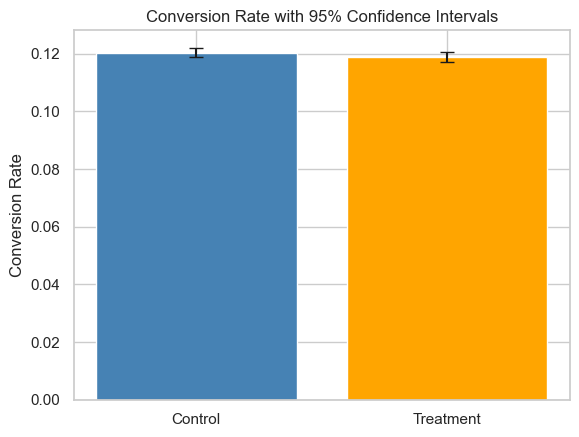

In [23]:
import matplotlib.pyplot as plt

rates = [control_rate, treatment_rate]

lower_bounds = [
    control_rate - control_ci[0],
    treatment_rate - treatment_ci[0]
]

upper_bounds = [
    control_ci[1] - control_rate,
    treatment_ci[1] - treatment_rate
]

errors = [lower_bounds, upper_bounds]

plt.bar(
    ["Control", "Treatment"],
    rates,
    yerr=errors,
    capsize=5,
    color=["steelblue", "orange"]
)

plt.title("Conversion Rate with 95% Confidence Intervals")
plt.ylabel("Conversion Rate")

plt.savefig("../visuals/conversion_confidence_intervals.png")

plt.show()

## Experiment Power and Sample Size

The experiment included approximately 294,000 users split evenly between control and treatment groups.

With this sample size, the experiment had sufficient power to detect small differences in conversion rates.

However, the observed difference between the variants was extremely small (~0.15%), suggesting that the new design does not meaningfully improve performance.